# 01 · EDA — recorrido exploratorio de `data/raw/`
**Fase CRISP-DM:** comprensión de los datos.

**Objetivo.** Recorrer todas las fuentes crudas (consultas de Trufi App, feed GTFS y Kontur Population 2023),
medir su estructura y calidad, explorar la variable objetivo candidata (consultas por zona H3 res 8) y sus
relaciones, y dejar escritos los pasos que debe aplicar el preprocesamiento.

**Entradas:** `data/raw/*.csv`, `data/raw/gtfs/*.txt`, `data/raw/kontur_population_BO_20231101.gpkg.gz`.

**Salidas:** solo `resultados/01_eda/` (tablas CSV, `figuras/`, `metricas.json`). Este notebook **no escribe
en `data/`**: todo se calcula en memoria; el preprocesamiento es quien construye los datasets.

| § | Sección | Pregunta |
|---|---|---|
| 1 | Entorno | — |
| 2 | Inventario | ¿Qué hay en `raw/` y qué período cubre? |
| 3–5 | Consultas | ¿Cómo están estructuradas, qué calidad tienen, cómo se reparten en el tiempo? |
| 6 | Espacio | ¿Dónde se originan las consultas? |
| 7 | GTFS | ¿Qué red describe el feed y cuánto se superpone con la demanda? |
| 8 | Kontur | ¿Dónde vive la población? |
| 9 | Variable objetivo | ¿Cómo se comporta `query_count` por zona? |
| 10–11 | Relaciones y espacio | ¿Con qué se asocia y cuánto se parecen las vecinas? |
| 12 | Cierre | Pasos para el preprocesamiento y métricas |

## 1 · Entorno
Ubica la raíz, carga los parámetros de `config.py`, borra `resultados/01_eda/` para regenerarlo e inicia un
cronómetro por sección.

In [1]:
# Bootstrap: la raíz es la carpeta con pyproject.toml; se agrega a sys.path para importar config y trufi_ds
import sys
from pathlib import Path

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

In [2]:
from trufi_ds.notebook_setup import *  # noqa: F403  config, pl, pd, np, plt, h3, guardar_*
from trufi_ds import eda, spatial
from trufi_ds import io as tio
from trufi_ds import preparation as prep
from trufi_ds import preprocesamiento as pre

import geopandas as gpd
from scipy.stats import spearmanr

FASE = "01_eda"
np.random.seed(config.SEMILLA)
limpiar_salidas(FASE)
M = {}  # métricas de la fase → metricas.json al cierre
tiempo = cronometro()  # imprime el tiempo de cada sección para ubicar las partes lentas

# Paleta: azul para magnitudes, gris para contexto, categorías en orden fijo
AZUL, NARANJA, AQUA, AMARILLO, GRIS, TINTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#c3c2b7", "#52514e"

## 2 · Inventario de `raw/`
Qué cubre cada fuente: período, tamaño y versión. **Salida:** `inventario_fuentes.csv`.

In [3]:
# Consultas: exportaciones semanales; el período sale del nombre (<inicio>_to_<fin>_<año>-<semana>.csv)
archivos = sorted(config.DATA_RAW.glob("*.csv"))
columnas = {a.name: tio.read_csv_safe(a, n_rows=0)[0].columns for a in archivos}
grupo = eda.grupos_esquema(columnas)
inicio = min(a.name[:10] for a in archivos)
fin = max(a.name.split("_to_")[1][:10] for a in archivos)
print(f"{len(archivos)} CSV, {len(set(grupo.values()))} esquemas, período {inicio} → {fin}")

85 CSV, 2 esquemas, período 2022-09-12 → 2024-06-09


In [4]:
# GTFS: todas las tablas del feed, como texto
gtfs = eda.leer_gtfs(config.GTFS_DIR)
feed = gtfs["feed_info"].iloc[0]
vigencia = f"{feed['feed_start_date']} → {feed['feed_end_date']}"
print(f"GTFS: {len(gtfs)} tablas {sorted(gtfs)}; vigencia declarada {vigencia}")

GTFS: 11 tablas ['agency', 'calendar', 'fare_attributes', 'fare_rules', 'feed_info', 'frequencies', 'routes', 'shapes', 'stop_times', 'stops', 'trips']; vigencia declarada 20240101 → 20261231


In [5]:
# Kontur Population 2023: población estimada por celda H3 (sin geometría: el id H3 basta para unir)
kontur = prep.load_kontur(config.KONTUR_2023_GPKG_GZ).sort("h3_cell")
assert {h3.get_resolution(c) for c in kontur["h3_cell"].head(1000)} == {config.H3_RES}, "Kontur no está en res 8"
print(f"Kontur 2023: {kontur.height:,} celdas res {config.H3_RES}, {kontur['population'].sum():,} habitantes (Bolivia)")

Kontur 2023: 145,929 celdas res 8, 12,431,735 habitantes (Bolivia)


In [6]:
inventario = pl.DataFrame([
    {"fuente": "consultas Trufi App", "archivos": len(archivos), "registros": None, "periodo": f"{inicio} → {fin}"},
    {"fuente": "GTFS Trufi Cochabamba", "archivos": len(gtfs), "registros": sum(len(t) for t in gtfs.values()),
     "periodo": vigencia},
    {"fuente": "Kontur Population 2023-11-01", "archivos": 1, "registros": kontur.height, "periodo": "estimación 2023"},
])
M.update({"csv_archivos": len(archivos), "csv_esquemas": len(set(grupo.values())), "periodo_inicio": inicio,
          "periodo_fin": fin, "gtfs_tablas": len(gtfs), "gtfs_vigencia": vigencia, "kontur_celdas": kontur.height,
          "kontur_poblacion_bolivia": int(kontur["population"].sum())})
tiempo("inventario")
guardar_tabla(inventario, "inventario_fuentes", FASE)

⏱ inventario: 2.7 s (acumulado 3 s)


fuente,archivos,registros,periodo
str,i64,i64,str
"""consultas Trufi App""",85,null,"""2022-09-12 → 2024-06-09"""
"""GTFS Trufi Cochabamba""",11,467553,"""20240101 → 20261231"""
"""Kontur Population 2023-11-01""",1,145929,"""estimación 2023"""


## 3 · Consultas: estructura
**Tipo de datos:** categóricos y de texto (esquema, columnas, codificación).
Se consolidan los CSV en memoria con linaje (`source_file`, `source_batch`, `source_encoding`). El lote de 2024
trae las coordenadas con nombre largo y dos columnas extra; algunos archivos vienen en Latin-1.
**Salida:** `archivos_consultas.csv`.

In [7]:
consultas, registro = tio.leer_consultas(archivos)
# Orden estable: los análisis que dependen del orden (primer duplicado, diferencias de tiempo) no varían
consultas = consultas.sort(["source_file", "ts", "userID", "lat_orig", "lon_orig", "lat_dest", "lon_dest"])
N_CRUDAS = consultas.height
assert N_CRUDAS == registro["filas"].sum(), "La consolidación perdió filas"
archivos_tab = registro.with_columns(pl.col("archivo").replace_strict(grupo, return_dtype=pl.Int64).alias("grupo_esquema"))
M.update({"consultas_crudas": N_CRUDAS, "csv_latin1": archivos_tab.filter(pl.col("codificacion") == "latin-1").height})
print(archivos_tab.group_by("lote", "codificacion", "grupo_esquema").agg(pl.len().alias("archivos"), pl.col("filas").sum()))
tiempo("estructura")
guardar_tabla(archivos_tab, "archivos_consultas", FASE).head()

shape: (2, 5)
┌─────────────────┬──────────────┬───────────────┬──────────┬─────────┐
│ lote            ┆ codificacion ┆ grupo_esquema ┆ archivos ┆ filas   │
│ ---             ┆ ---          ┆ ---           ┆ ---      ┆ ---     │
│ str             ┆ str          ┆ i64           ┆ u32      ┆ i64     │
╞═════════════════╪══════════════╪═══════════════╪══════════╪═════════╡
│ lote_original   ┆ utf-8        ┆ 0             ┆ 79       ┆ 1765898 │
│ lote_2024_nuevo ┆ latin-1      ┆ 1             ┆ 6        ┆ 161777  │
└─────────────────┴──────────────┴───────────────┴──────────┴─────────┘
⏱ estructura: 9.4 s (acumulado 12 s)


archivo,lote,codificacion,n_columnas,filas,grupo_esquema
str,str,str,i64,i64,i64
"""2022-09-12_to_2022-09-18_2022-…","""lote_original""","""utf-8""",13,5049,0
"""2022-09-19_to_2022-09-25_2022-…","""lote_original""","""utf-8""",13,10838,0
"""2022-09-26_to_2022-10-02_2022-…","""lote_original""","""utf-8""",13,10850,0
"""2022-10-03_to_2022-10-09_2022-…","""lote_original""","""utf-8""",13,11438,0
"""2022-10-10_to_2022-10-16_2022-…","""lote_original""","""utf-8""",13,11443,0


## 4 · Consultas: calidad
**Tipo de datos:** categóricos y numéricos (nulos, duplicados, coordenadas, distancia, uso por usuario).
Nulos, duplicados, coordenadas imposibles, unidad y rango de `distancia` y uso anómalo por usuario. Cada problema
se mide sobre las filas crudas (los conteos pueden solaparse). **Salidas:** `nulos.csv`, `duplicados.csv`,
`distancia.csv`, `usuarios_senales.csv`, `calidad_resumen.csv`.

In [8]:
# Nulos por columna y lote: las columnas exclusivas de un lote son nulos estructurales, no pérdida de datos
nulos = eda.perfil_nulos(consultas)
guardar_tabla(nulos, "nulos", FASE).filter(pl.col("pct_global") > 0)

columna,pct_global,lote_2024_nuevo,lote_original
str,f64,f64,f64
"""time_of_day""",91.608,0.0,100.0
"""year_week_number""",91.608,0.0,100.0


In [9]:
# Cuatro definiciones de duplicado: exacto (todas las columnas de datos) y variantes por OD, tiempo y usuario
datos_cols = [c for c in consultas.columns if c not in tio.LINAJE]
definiciones = {
    "exacto": datos_cols,
    "od_ts": ["lat_orig", "lon_orig", "lat_dest", "lon_dest", "ts"],
    "usuario_ts": ["userID", "ts"],
    "od_ts_usuario": ["lat_orig", "lon_orig", "lat_dest", "lon_dest", "ts", "userID"],
}
dups = eda.duplicados(consultas, definiciones)
M["duplicados_exactos_copias"] = int(dups.filter(pl.col("definicion") == "exacto")["copias_sobrantes"].item())
guardar_tabla(dups, "duplicados", FASE)

definicion,columnas,filas_implicadas,copias_sobrantes,pct_copias
str,str,i64,i64,f64
"""exacto""","""date, lat_orig, lon_orig, lat_…",104,60,0.0031
"""od_ts""","""lat_orig, lon_orig, lat_dest, …",104,60,0.0031
"""usuario_ts""","""userID, ts""",137,90,0.0047
"""od_ts_usuario""","""lat_orig, lon_orig, lat_dest, …",104,60,0.0031


In [10]:
# Coordenadas: (0,0) es un GPS sin señal; fuera del rectángulo de Bolivia es imposible para esta app
lat, lon = pl.col("lat_orig"), pl.col("lon_orig")
BB = config.BBOX_BOLIVIA
cero = (lat == 0) | (lon == 0)
en_bolivia = lat.is_between(BB["lat_min"], BB["lat_max"]) & lon.is_between(BB["lon_min"], BB["lon_max"])
coords_ok = ~cero & en_bolivia
M.update({"origen_cero": consultas.filter(cero).height,
          "origen_fuera_bolivia": consultas.filter(~cero & ~en_bolivia).height})
print({k: M[k] for k in ("origen_cero", "origen_fuera_bolivia")})

{'origen_cero': 3, 'origen_fuera_bolivia': 9}


In [11]:
# distancia: se contrasta con la geodésica recalculada para confirmar la unidad; luego percentiles y colas
M.update(eda.verificar_unidad_distancia(consultas, 200_000, config.SEMILLA))
d_km = consultas.filter(coords_ok & (pl.col("distancia") > 0))["distancia"].to_numpy() / 1000
filas = [{"medida": f"P{p}", "km": round(float(np.percentile(d_km, p)), 2)} for p in (50, 90, 99, 99.9)]
filas += [{"medida": f"pct_mayor_{u}km", "km": round(float((d_km > u).mean() * 100), 3)} for u in (20, 30, 40, 50)]
M.update({"distancia_p50_km": filas[0]["km"], "distancia_p99_9_km": filas[3]["km"],
          "distancia_pct_mayor_umbral": round(float((d_km > config.DIST_MAX_M / 1000).mean() * 100), 3)})
print({k: v for k, v in M.items() if k.startswith("distancia")})
guardar_tabla(pl.DataFrame(filas), "distancia", FASE)

{'distancia_unidad': 'metros', 'distancia_error_mediano_pct': 0.142, 'distancia_correlacion_geodesica': 1.0, 'distancia_p50_km': 3.39, 'distancia_p99_9_km': 40.7, 'distancia_pct_mayor_umbral': 0.04}


medida,km
str,f64
"""P50""",3.39
"""P90""",10.26
"""P99""",19.69
"""P99.9""",40.7
"""pct_mayor_20km""",0.961
"""pct_mayor_30km""",0.353
"""pct_mayor_40km""",0.109
"""pct_mayor_50km""",0.04


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/01_eda/figuras/distancia.png')

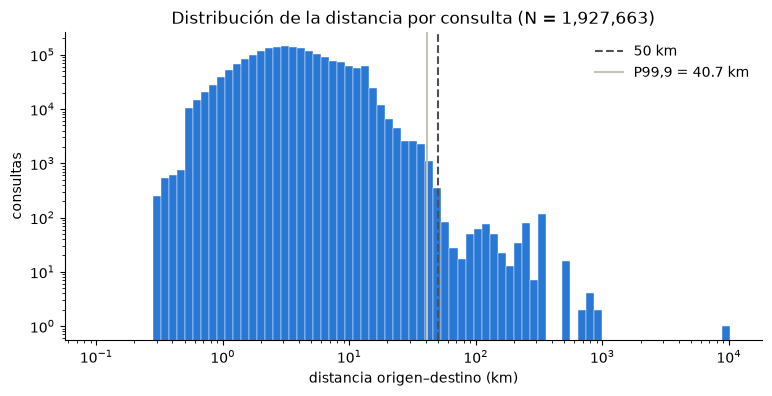

In [12]:
# Cola > 40 km (≈ P99,9): ya no es movilidad dentro del eje metropolitano; un umbral de 50 km la separa
# sin cortar los viajes largos del valle alto hacia la ciudad
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(d_km, bins=np.logspace(-1, np.log10(d_km.max()), 80), color=AZUL, edgecolor="white", linewidth=0.3)
ax.axvline(config.DIST_MAX_M / 1000, color=TINTA, lw=1.5, ls="--", label=f"{config.DIST_MAX_M // 1000} km")
ax.axvline(np.percentile(d_km, 99.9), color=GRIS, lw=1.5, label=f"P99,9 = {np.percentile(d_km, 99.9):.1f} km")
ax.set(xscale="log", yscale="log", xlabel="distancia origen–destino (km)", ylabel="consultas",
       title=f"Distribución de la distancia por consulta (N = {d_km.size:,})")
ax.legend(frameon=False)
guardar_figura(fig, "distancia", FASE)

In [13]:
# Uso anómalo: seis señales por usuario (volumen, intensidad, dispersión, ráfaga, sin rutina, rapidez);
# se exige al menos MIN_SENALES para no marcar a usuarios intensivos legítimos
# Misma función que usa el preprocesamiento: ambos notebooks marcan a los mismos usuarios
usuarios = pre.senales_por_usuario(consultas)
anomalos = usuarios.filter(pl.col("anomalo")).select("userID", "n_consultas", "n_senales")

In [14]:
senales = pl.DataFrame([{"senal": s, "usuarios": int(usuarios[s].sum())} for s in usuarios.columns if s.startswith("s_")])
M.update({"usuarios": usuarios.height, "usuarios_anomalos": anomalos.height,
          "usuarios_mediana_consultas": float(usuarios["n_consultas"].median()),
          "usuarios_una_senal_rapido": int(usuarios["s_rapido"].sum()),
          "consultas_de_anomalos": int(anomalos["n_consultas"].sum())})
print({k: M[k] for k in ("usuarios", "usuarios_anomalos", "usuarios_mediana_consultas", "consultas_de_anomalos")})
guardar_tabla(senales, "usuarios_senales", FASE)

{'usuarios': 130545, 'usuarios_anomalos': 2, 'usuarios_mediana_consultas': 5.0, 'consultas_de_anomalos': 233}


senal,usuarios
str,i64
"""s_volumen""",1
"""s_intensidad""",1
"""s_dispersion""",0
"""s_rafaga""",1
"""s_sin_rutina""",0
"""s_rapido""",10511


In [15]:
# Resumen de calidad sobre filas crudas (no excluyentes entre sí)
calidad = pl.DataFrame([
    {"problema": "origen (0,0)", "filas": M["origen_cero"]},
    {"problema": "origen fuera de Bolivia", "filas": M["origen_fuera_bolivia"]},
    {"problema": "copia de duplicado exacto", "filas": M["duplicados_exactos_copias"]},
    {"problema": f"distancia > {config.DIST_MAX_M // 1000} km", "filas": consultas.filter(pl.col("distancia") > config.DIST_MAX_M).height},
    {"problema": "consulta de usuario anómalo", "filas": M["consultas_de_anomalos"]},
]).with_columns((pl.col("filas") / N_CRUDAS * 100).round(3).alias("pct"))
tiempo("calidad")
guardar_tabla(calidad, "calidad_resumen", FASE)

⏱ calidad: 33.8 s (acumulado 46 s)


problema,filas,pct
str,i64,f64
"""origen (0,0)""",3,0.0
"""origen fuera de Bolivia""",9,0.0
"""copia de duplicado exacto""",60,0.003
"""distancia > 50 km""",778,0.04
"""consulta de usuario anómalo""",233,0.012


## 5 · Consultas: tiempo
**Tipo de datos:** temporales (semanas, horas, días de la semana).
Semanas con datos, hueco, semanas parciales (menos de 7 días con datos) y perfil por hora y día. Se cuentan filas
sin copias duplicadas (dos archivos repiten la última semana de 2022).
**Salidas:** `cobertura_semanal.csv`, `perfil_temporal.csv`.

In [16]:
unicas = consultas.filter(pl.struct(datos_cols).is_first_distinct())
semanal = eda.cobertura_semanal(unicas)
faltan = semanal.filter(~pl.col("observada"))
parciales = semanal.filter(pl.col("observada") & ~pl.col("completa"))
# Hueco = semanas faltantes consecutivas; la media semanal se compara solo con semanas completas
i0, i1 = semanal["observada"].arg_min(), semanal.with_row_index().filter(~pl.col("observada"))["index"].max()
media = lambda s: round(s.filter(pl.col("completa"))["consultas"].mean())
M.update({"semanas_calendario": semanal.height, "semanas_observadas": int(semanal["observada"].sum()),
          "semanas_completas": int(semanal["completa"].sum()), "semanas_parciales": parciales.height,
          "semanas_faltantes": faltan.height, "hueco_desde": str(faltan["inicio"].min()),
          "hueco_hasta": str(faltan["inicio"].max()), "media_semanal_antes_hueco": media(semanal[:i0]),
          "media_semanal_despues_hueco": media(semanal[i1 + 1:])})
guardar_tabla(semanal, "cobertura_semanal", FASE)
parciales.select("inicio", "consultas", "dias_con_datos")

inicio,consultas,dias_con_datos
date,u32,u32
2023-07-24,13311,5
2024-01-29,20340,5
2024-02-05,16224,4
2024-03-04,33843,6
2024-04-29,932,1
2024-06-03,1386,1


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/01_eda/figuras/cobertura_semanal.png')

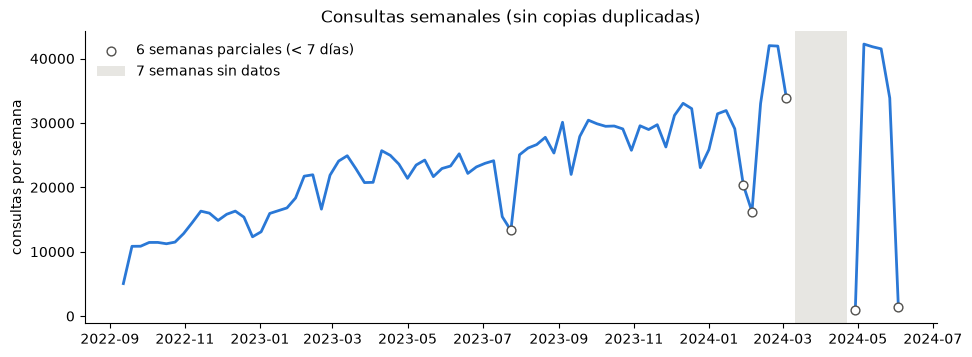

In [17]:
# Las semanas sin datos quedan vacías (no en cero) para no dibujar una caída que no existe
serie = semanal.with_columns(pl.when(pl.col("observada")).then(pl.col("consultas")).alias("y"))
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(serie["inicio"], serie["y"].cast(pl.Float64).fill_null(np.nan), color=AZUL, lw=2)
ax.scatter(parciales["inicio"], parciales["consultas"], s=40, facecolor="white", edgecolor=TINTA, zorder=3,
           label=f"{parciales.height} semanas parciales (< 7 días)")
ax.axvspan(faltan["inicio"].min(), faltan["inicio"].max(), color=GRIS, alpha=0.4, lw=0,
           label=f"{faltan.height} semanas sin datos")
ax.set(ylabel="consultas por semana", title="Consultas semanales (sin copias duplicadas)")
ax.legend(frameon=False, loc="upper left")
guardar_figura(fig, "cobertura_semanal", FASE)

⏱ tiempo: 9.5 s (acumulado 55 s)


dimension,valor,consultas,pct
str,i32,u32,f64
"""dia_semana""",1,276253,14.331
"""dia_semana""",2,283311,14.697
"""dia_semana""",3,302545,15.695


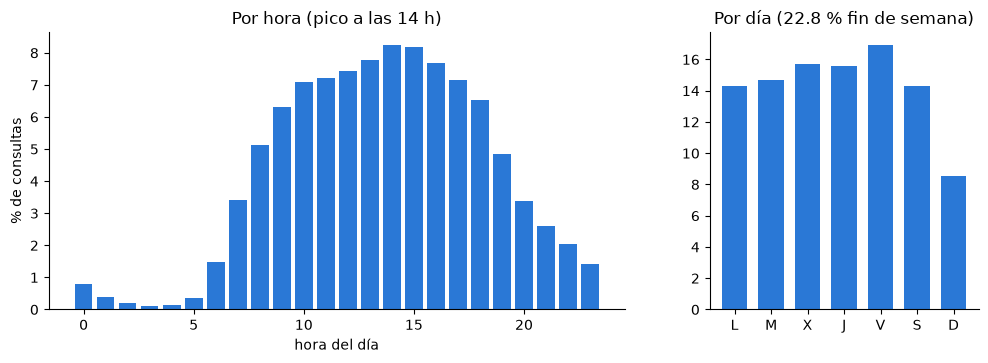

In [18]:
perfil = eda.perfil_temporal(unicas)
hora, dia = perfil.filter(pl.col("dimension") == "hora"), perfil.filter(pl.col("dimension") == "dia_semana")
M.update({"hora_pico": int(hora.sort("pct", descending=True)["valor"][0]),
          "pct_fin_de_semana": round(float(dia.filter(pl.col("valor") >= 6)["pct"].sum()), 1)})
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [3, 1.4]})
a1.bar(hora["valor"], hora["pct"], color=AZUL, width=0.8)
a1.set(xlabel="hora del día", ylabel="% de consultas", title=f"Por hora (pico a las {M['hora_pico']} h)")
a2.bar(["L", "M", "X", "J", "V", "S", "D"], dia["pct"], color=AZUL, width=0.7)
a2.set(title=f"Por día ({M['pct_fin_de_semana']} % fin de semana)")
guardar_figura(fig, "perfil_temporal", FASE)
tiempo("tiempo")
guardar_tabla(perfil, "perfil_temporal", FASE).head(3)

## 6 · Consultas: espacio
**Tipo de datos:** espaciales (coordenadas, celdas H3).
¿Dónde se originan las consultas? Se toman los orígenes con coordenadas correctas de usuarios no anómalos, sin
condición de distancia, y se prueba qué región los contiene: la envolvente de todas las celdas H3 ocupadas o de
su componente contigua principal (k = 1, 2, 3). **Salida:** `area_variantes.csv`.

In [19]:
es_anomalo = pl.col("userID").is_in(anomalos["userID"].implode())
origenes = prep.add_cells(consultas.filter(coords_ok & ~es_anomalo).select("lat_orig", "lon_orig"),
                          "lat_orig", "lon_orig", "h3_origin")
ocupadas = set(origenes["h3_origin"].unique().to_list())
lat_o, lon_o = origenes["lat_orig"].to_numpy(), origenes["lon_orig"].to_numpy()
M.update({"origenes_validos": origenes.height, "celdas_ocupadas": len(ocupadas)})
print(f"Orígenes válidos: {origenes.height:,} en {len(ocupadas):,} celdas H3 ocupadas")

Orígenes válidos: 1,927,430 en 1,516 celdas H3 ocupadas


In [20]:
# Sin componente, la envolvente se estira hasta orígenes aislados en otras ciudades;
# con k > 1 se suman cientos de km² casi vacíos por muy pocas consultas
variantes, geoms = [], {}
for k in [None, 1, 2, 3]:
    celdas_k = ocupadas if k is None else prep.main_component(ocupadas, k)
    pts = origenes.filter(pl.col("h3_origin").is_in(list(celdas_k))).unique(["lat_orig", "lon_orig"])
    geoms[k], km2 = prep.hull_area(pts["lat_orig"].to_numpy(), pts["lon_orig"].to_numpy(), config.BUFFER_AREA_M)
    dentro = prep.points_in(geoms[k], lat_o, lon_o)
    variantes.append({"regla": "todas las celdas" if k is None else f"componente k={k}", "celdas": len(celdas_k),
                      "area_km2": round(km2, 1), "pct_origenes_dentro": round(float(dentro.mean() * 100), 3)})
guardar_tabla(pl.DataFrame(variantes), "area_variantes", FASE)

regla,celdas,area_km2,pct_origenes_dentro
str,i64,f64,f64
"""todas las celdas""",1516,485940.1,100.0
"""componente k=1""",919,1505.7,99.87
"""componente k=2""",1076,1965.4,99.933
"""componente k=3""",1195,3040.9,99.962


In [21]:
# Región de referencia para el resto del EDA (el preprocesamiento la formaliza con la misma regla)
AREA = geoms[config.K_COMPONENTE]
CENTRO = prep.area_center(AREA)
dentro = prep.points_in(AREA, lat_o, lon_o)
PLAZA = config.PLAZA_14_SEPTIEMBRE
M.update({"area_km2": round(prep.area_km2(AREA), 1), "area_pct_origenes_dentro": round(float(dentro.mean() * 100), 3),
          "area_todas_celdas_km2": variantes[0]["area_km2"],
          "area_centro_a_plaza_km": round(float(prep.haversine_km(np.array([CENTRO[0]]), np.array([CENTRO[1]]),
                                                                   PLAZA["lat"], PLAZA["lon"])[0]), 2)})
print({k: M[k] for k in ("area_km2", "area_pct_origenes_dentro", "area_centro_a_plaza_km")})

{'area_km2': 1505.7, 'area_pct_origenes_dentro': 99.87, 'area_centro_a_plaza_km': 7.82}


⏱ espacio: 21.1 s (acumulado 76 s)


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/01_eda/figuras/origenes_region.png')

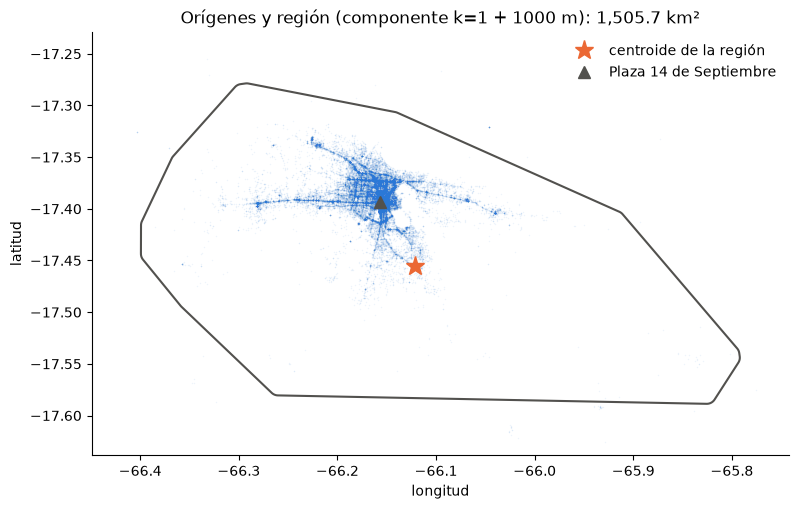

In [22]:
muestra = np.random.default_rng(config.SEMILLA).choice(lat_o.size, 60_000, replace=False)
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(lon_o[muestra], lat_o[muestra], s=1, color=AZUL, alpha=0.08, lw=0)
gpd.GeoSeries([AREA], crs="EPSG:4326").boundary.plot(ax=ax, color=TINTA, lw=1.5)
ax.plot(CENTRO[1], CENTRO[0], marker="*", color=NARANJA, ms=14, ls="", label="centroide de la región")
ax.plot(PLAZA["lon"], PLAZA["lat"], marker="^", color=TINTA, ms=8, ls="", label="Plaza 14 de Septiembre")
minx, miny, maxx, maxy = AREA.bounds
ax.set(xlim=(minx - 0.05, maxx + 0.05), ylim=(miny - 0.05, maxy + 0.05), xlabel="longitud", ylabel="latitud",
       title=f"Orígenes y región (componente k={config.K_COMPONENTE} + {config.BUFFER_AREA_M} m): {M['area_km2']:,} km²")
ax.legend(frameon=False, loc="upper right")
tiempo("espacio")
guardar_figura(fig, "origenes_region", FASE)

## 7 · GTFS
**Tipo de datos:** espaciales y de red (líneas, trazados, paradas, frecuencias).
Qué red describe el feed (líneas, trazados, paradas, frecuencias), su vigencia frente al período de las consultas
y cuánto de la demanda queda cerca del trazado. **Salida:** `gtfs_resumen.csv`.

In [23]:
resumen_gtfs = eda.resumen_gtfs(gtfs)
g_val = dict(resumen_gtfs.iter_rows())
paradas = gtfs["stops"].dropna(subset=["stop_lat", "stop_lon"]).astype({"stop_lat": float, "stop_lon": float})
en_region = prep.points_in(AREA, paradas["stop_lat"].to_numpy(), paradas["stop_lon"].to_numpy())
M.update({"gtfs_agencias": int(g_val["filas_agency"]), "gtfs_lineas": int(g_val["filas_routes"]),
          "gtfs_recorridos": int(g_val["filas_trips"]), "gtfs_paradas": int(g_val["filas_stops"]),
          "gtfs_trazado_mediana_km": g_val["trazado_mediana_km"], "gtfs_frecuencia_mediana_min": g_val.get("frecuencia_mediana_min"),
          "gtfs_pct_paradas_en_region": round(float(en_region.mean() * 100), 1),
          "gtfs_vigencia_posterior_al_inicio": feed["feed_start_date"] > inicio.replace("-", "")})
guardar_tabla(resumen_gtfs, "gtfs_resumen", FASE)

medida,valor
str,f64
"""filas_agency""",43.0
"""filas_calendar""",2.0
"""filas_fare_attributes""",626.0
"""filas_fare_rules""",626.0
"""filas_feed_info""",1.0
…,…
"""trazados""",626.0
"""trazado_mediana_km""",20.22
"""trazados_total_km""",12737.3


In [24]:
# Distancia de cada origen válido al trazado más cercano (UTM 19S, trazado muestreado cada MUESTREO_TRAZADO_M)
d_trazado = spatial.distancia_trazado_m(lat_o[dentro], lon_o[dentro], config.GTFS_DIR, config.MUESTREO_TRAZADO_M)
M.update({"pct_origenes_cerca_trazado": round(float((d_trazado <= config.COBERTURA_M).mean() * 100), 2),
          "origenes_distancia_trazado_p90_m": round(float(np.percentile(d_trazado, 90)))})
print({k: M[k] for k in ("pct_origenes_cerca_trazado", "origenes_distancia_trazado_p90_m")})

{'pct_origenes_cerca_trazado': 99.47, 'origenes_distancia_trazado_p90_m': 82}


⏱ gtfs: 18.9 s (acumulado 95 s)


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/01_eda/figuras/gtfs_red_y_demanda.png')

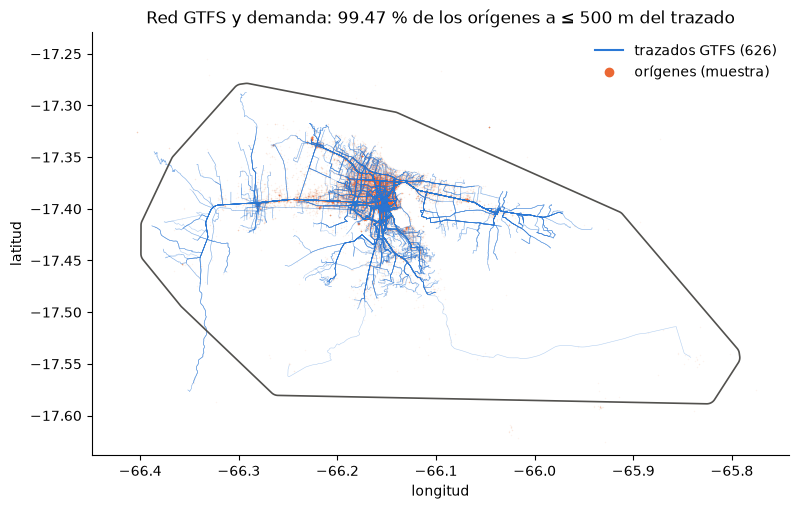

In [25]:
from matplotlib.collections import LineCollection

shp = gtfs["shapes"].astype({"shape_pt_lat": float, "shape_pt_lon": float, "shape_pt_sequence": int})
lineas = [s[["shape_pt_lon", "shape_pt_lat"]].to_numpy()
          for _, s in shp.sort_values(["shape_id", "shape_pt_sequence"]).groupby("shape_id")]
fig, ax = plt.subplots(figsize=(9, 8))
ax.add_collection(LineCollection(lineas, colors=AZUL, linewidths=0.4, alpha=0.35))  # un solo objeto: dibujo rápido
ax.scatter(lon_o[muestra], lat_o[muestra], s=1, color=NARANJA, alpha=0.08, lw=0)
gpd.GeoSeries([AREA], crs="EPSG:4326").boundary.plot(ax=ax, color=TINTA, lw=1.2)
ax.plot([], [], color=AZUL, label=f"trazados GTFS ({int(g_val['trazados'])})")
ax.plot([], [], ls="", marker="o", color=NARANJA, label="orígenes (muestra)")
ax.set(xlim=(minx - 0.05, maxx + 0.05), ylim=(miny - 0.05, maxy + 0.05), xlabel="longitud", ylabel="latitud",
       title=f"Red GTFS y demanda: {M['pct_origenes_cerca_trazado']} % de los orígenes a ≤ {config.COBERTURA_M} m del trazado")
ax.legend(frameon=False, loc="upper right")
tiempo("gtfs")
guardar_figura(fig, "gtfs_red_y_demanda", FASE)

## 8 · Kontur Population 2023
**Tipo de datos:** espaciales y numéricos (población por celda).
Dónde vive la población dentro de la región y cuántas zonas pobladas no registran consultas.
**Salida:** `kontur_resumen.csv`.

In [26]:
k_lat, k_lon = prep.cell_centroids(kontur["h3_cell"].to_list())
k_region = kontur.filter(pl.Series(prep.points_in(AREA, k_lat, k_lon)))
pob = k_region["population"].to_numpy()
sin_consultas = k_region.filter(~pl.col("h3_cell").is_in(list(ocupadas)))
kontur_res = {"celdas_region": k_region.height, "poblacion_region": int(pob.sum()),
              "poblacion_mediana_celda": float(np.median(pob)), "celdas_menos_de_pop_min": int((pob < config.POP_MIN).sum()),
              "celdas_pobladas_sin_consultas": sin_consultas.height,
              "poblacion_en_celdas_sin_consultas": int(sin_consultas["population"].sum())}
M.update({f"kontur_{k}": v for k, v in kontur_res.items()})
tiempo("kontur")
guardar_tabla(pl.DataFrame({"medida": list(kontur_res), "valor": [float(v) for v in kontur_res.values()]}), "kontur_resumen", FASE)

⏱ kontur: 2.3 s (acumulado 98 s)


medida,valor
str,f64
"""celdas_region""",1577.0
"""poblacion_region""",1.223871e6
"""poblacion_mediana_celda""",254.0
"""celdas_menos_de_pop_min""",202.0
"""celdas_pobladas_sin_consultas""",609.0
"""poblacion_en_celdas_sin_consul…",57157.0


## 9 · Variable objetivo (exploración)
**Tipo de datos:** numéricos (conteo de consultas por zona).
`query_count` = consultas con origen en cada zona H3 res 8. Se calcula en memoria aplicando los filtros candidatos
en orden, para medir cuánto quita cada uno (flujo tentativo), y se unen las zonas Kontur de la región con 0.
El preprocesamiento lo construye y lo guarda. **Salidas:** `flujo_candidato.csv`, `objetivo_resumen.csv`.

In [27]:
# Orden: (0,0) → fuera de Bolivia → copias exactas → fuera de la región → distancia > DIST_MAX_M → usuario anómalo
limpias, flujo = prep.clean_queries(consultas, AREA, anomalos["userID"], config.DIST_MAX_M)
flujo = flujo.with_columns((pl.col("filas_despues") / N_CRUDAS * 100).round(3).alias("pct_conservado"))
celdas = prep.build_cell_table(limpias, kontur, AREA)
lat_c, lon_c = prep.cell_centroids(celdas["h3_cell"].to_list())
celdas = celdas.with_columns(pl.Series("lat", lat_c), pl.Series("lon", lon_c)).sort("h3_cell")
M.update({"consultas_validas": limpias.height, "pct_consultas_validas": round(limpias.height / N_CRUDAS * 100, 2)})
guardar_tabla(flujo, "flujo_candidato", FASE)

regla,filas_eliminadas,filas_despues,pct_conservado
str,i64,i64,f64
"""consultas crudas""",0,1927675,100.0
"""origen (0,0)""",3,1927672,100.0
"""origen fuera de Bolivia""",9,1927663,99.999
"""copia de duplicado exacto""",60,1927603,99.996
"""origen fuera del área de estud…",2509,1925094,99.866
"""distancia > 50 km""",283,1924811,99.851
"""usuario anómalo""",233,1924578,99.839


In [28]:
# La tasa por habitante solo se calcula con population ≥ POP_MIN: con pocos habitantes es inestable
q, pob_c = celdas["query_count"].to_numpy(), celdas["population"].to_numpy()
modelo = celdas.filter(pl.col("population") >= config.POP_MIN).with_columns(
    (pl.col("query_count") / pl.col("population") * 1000).alias("tasa_1000"))
qm = modelo["query_count"].to_numpy()
resumen = {
    "celdas_region": celdas.height, "celdas_con_consultas": int((q > 0).sum()),
    "celdas_poblacion_min": modelo.height, "pct_ceros_poblacion_min": round(float((qm == 0).mean() * 100), 2),
    "media_query_count": round(float(qm.mean()), 1), "varianza_sobre_media": round(float(qm.var() / qm.mean()), 1),
    "gini_query_count": round(prep.gini(qm), 3),
    "pct_consultas_top10_celdas": round(float(np.sort(qm)[::-1][:10].sum() / qm.sum() * 100), 1),
    "tasa_global_1000": round(float(qm.sum() / modelo["population"].sum() * 1000), 1),
    "tasa_mediana_1000": round(float(modelo["tasa_1000"].median()), 1),
}
M.update(resumen)
guardar_tabla(pl.DataFrame({"medida": list(resumen), "valor": [float(v) for v in resumen.values()]}), "objetivo_resumen", FASE)

medida,valor
str,f64
"""celdas_region""",1628.0
"""celdas_con_consultas""",1017.0
"""celdas_poblacion_min""",1381.0
"""pct_ceros_poblacion_min""",32.15
"""media_query_count""",1393.4
"""varianza_sobre_media""",46569.0
"""gini_query_count""",0.948
"""pct_consultas_top10_celdas""",42.0
"""tasa_global_1000""",1570.0


⏱ objetivo: 14.2 s (acumulado 112 s)


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/01_eda/figuras/objetivo_distribucion.png')

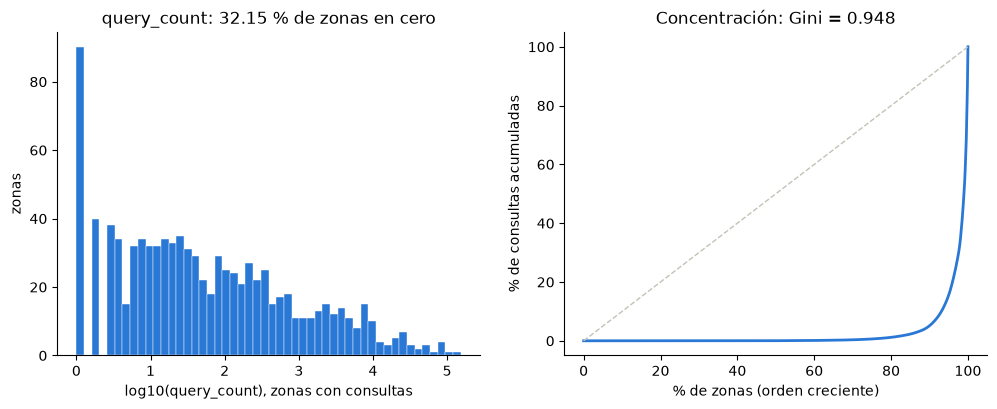

In [29]:
# Izquierda: distribución (log) de las zonas con consultas; derecha: curva de Lorenz
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
a1.hist(np.log10(qm[qm > 0]), bins=50, color=AZUL, edgecolor="white", linewidth=0.3)
a1.set(xlabel="log10(query_count), zonas con consultas", ylabel="zonas",
       title=f"query_count: {resumen['pct_ceros_poblacion_min']} % de zonas en cero")
lx, ly = eda.lorenz(qm)
a2.plot(lx * 100, ly * 100, color=AZUL, lw=2)
a2.plot([0, 100], [0, 100], color=GRIS, lw=1, ls="--")
a2.set(xlabel="% de zonas (orden creciente)", ylabel="% de consultas acumuladas",
       title=f"Concentración: Gini = {resumen['gini_query_count']}")
tiempo("objetivo")
guardar_figura(fig, "objetivo_distribucion", FASE)

## 10 · Relaciones entre variables
**Tipo de datos:** numéricos (asociación entre variables, sin causalidad).
Asociación (Spearman) del conteo y de la tasa con la población de la zona y de sus coronas H3, la distancia al
centro (centroide de la región y Plaza), la distancia al trazado GTFS y el municipio. Son asociaciones
exploratorias, no efectos. **Salidas:** `relaciones.csv`, `objetivo_por_municipio.csv`.

In [30]:
ctx = prep.add_territorial_features(modelo, kontur, AREA, CENTRO)
ctx = prep.add_municipality(ctx, limpias).with_columns(
    pl.Series("dist_plaza_km", prep.haversine_km(ctx["lat"].to_numpy(), ctx["lon"].to_numpy(), PLAZA["lat"], PLAZA["lon"])),
    pl.Series("dist_trazado_m", spatial.distancia_trazado_m(ctx["lat"].to_numpy(), ctx["lon"].to_numpy(),
                                                            config.GTFS_DIR, config.MUESTREO_TRAZADO_M)))
ctx = ctx.with_columns((pl.col("dist_trazado_m") <= config.COBERTURA_M).alias("cubierta"))
print(f"Zonas cubiertas (≤ {config.COBERTURA_M} m del trazado): {ctx['cubierta'].sum():,} de {ctx.height:,}")

Zonas cubiertas (≤ 500 m del trazado): 626 de 1,381


In [31]:
variables = ["population", "pop_ring1", "pop_ring2", "dist_centro_km", "dist_plaza_km", "dist_trazado_m"]
filas = []
for v in variables:
    for obj in ["query_count", "tasa_1000"]:
        rho, p = spearmanr(ctx[v].to_numpy(), ctx[obj].to_numpy())
        filas.append({"variable": v, "objetivo": obj, "spearman": round(float(rho), 3), "p_valor": float(p)})
M.update({f"spearman_{r['objetivo']}_{r['variable']}": r["spearman"] for r in filas})
guardar_tabla(pl.DataFrame(filas), "relaciones", FASE)

variable,objetivo,spearman,p_valor
str,str,f64,f64
"""population""","""query_count""",0.855,0.0
"""population""","""tasa_1000""",0.71,1.2482e-212
"""pop_ring1""","""query_count""",0.836,0.0
"""pop_ring1""","""tasa_1000""",0.721,3.2992e-222
"""pop_ring2""","""query_count""",0.804,0.0
…,…,…,…
"""dist_centro_km""","""tasa_1000""",-0.485,2.0669e-82
"""dist_plaza_km""","""query_count""",-0.697,4.8867e-201
"""dist_plaza_km""","""tasa_1000""",-0.677,1.6079e-185


In [32]:
# Contraste por cobertura: tasa mediana cerca y lejos del trazado (asociación descriptiva)
cob = ctx.group_by("cubierta").agg(pl.len().alias("zonas"), pl.col("tasa_1000").median().alias("tasa_mediana"),
                                   pl.col("query_count").sum().alias("consultas")).sort("cubierta")
fila = lambda c: cob.filter(pl.col("cubierta") == c)
M.update({"zonas_cubiertas": int(ctx["cubierta"].sum()),
          "pct_consultas_zonas_cubiertas": round(float(fila(True)["consultas"].item() / cob["consultas"].sum() * 100), 1),
          "tasa_mediana_cubiertas": round(float(fila(True)["tasa_mediana"].item()), 1),
          "tasa_mediana_no_cubiertas": round(float(fila(False)["tasa_mediana"].item()), 1)})
cob

cubierta,zonas,tasa_mediana,consultas
bool,u32,f64,i64
false,755,0.0,13038
true,626,117.952749,1911298


In [33]:
por_mun = (ctx.group_by("municipality").agg(pl.len().alias("zonas"), pl.col("population").sum(), pl.col("query_count").sum())
           .with_columns((pl.col("query_count") / pl.col("population") * 1000).round(1).alias("tasa_1000"))
           .sort(["query_count", "municipality"], descending=[True, False]))
M["municipios_en_region"] = por_mun.height
guardar_tabla(por_mun, "objetivo_por_municipio", FASE).head(8)

municipality,zonas,population,query_count,tasa_1000
str,u32,i64,i64,f64
"""Cochabamba""",318,622120,1662310,2672.0
"""Sacaba""",259,180427,90113,499.4
"""Quillacollo""",137,146291,65275,446.2
"""Colcapirhua""",35,47652,53209,1116.6
"""Tiquipaya""",47,60991,46785,767.1
"""Vinto""",89,56167,3403,60.6
"""Sipesipe""",92,35950,1357,37.7
"""Arbieto""",86,17368,546,31.4


⏱ relaciones: 8.8 s (acumulado 121 s)


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/01_eda/figuras/objetivo_vs_poblacion.png')

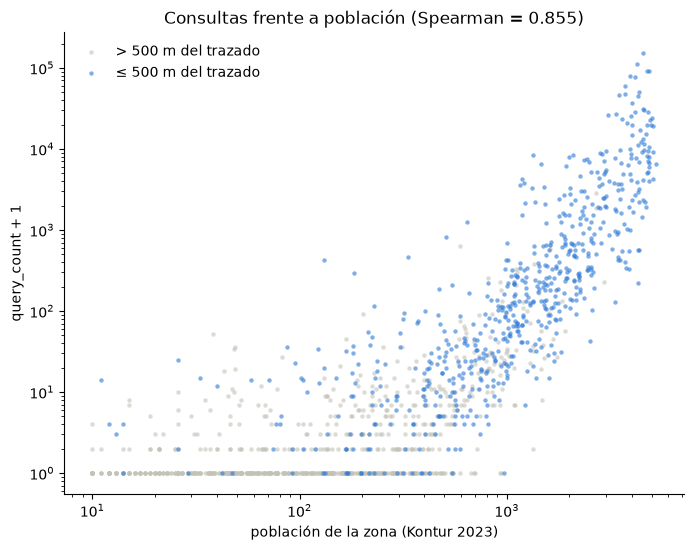

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))
for cub, color, etiqueta in [(False, GRIS, f"> {config.COBERTURA_M} m del trazado"),
                             (True, AZUL, f"≤ {config.COBERTURA_M} m del trazado")]:
    s = ctx.filter(pl.col("cubierta") == cub)
    ax.scatter(s["population"], s["query_count"] + 1, s=10, color=color, alpha=0.6, lw=0, label=etiqueta)
ax.set(xscale="log", yscale="log", xlabel="población de la zona (Kontur 2023)", ylabel="query_count + 1",
       title=f"Consultas frente a población (Spearman = {M['spearman_query_count_population']})")
ax.legend(frameon=False)
tiempo("relaciones")
guardar_figura(fig, "objetivo_vs_poblacion", FASE)

## 11 · Autocorrelación espacial
**Tipo de datos:** espaciales (vecindad H3, clusters locales).
¿Se parecen las zonas vecinas (I de Moran), hasta qué distancia (correlograma por anillo H3) y dónde están los
clusters (LISA)? Se usa `log(1 + tasa)` para que unas pocas zonas extremas no dominen.
**Salida:** `autocorrelacion.csv`.

In [35]:
zonas = ctx["h3_cell"].to_list()
y_tasa = np.log1p(ctx["tasa_1000"].to_numpy())
corr = eda.correlograma_moran(y_tasa, zonas, config.K_MAX_CORRELOGRAMA, config.PERMUTACIONES, config.SEMILLA)
# Distancia entre centros de anillos H3 res 8 ≈ 0,92 km por orden (2 × apotema)
corr = corr.with_columns((pl.col("orden_k") * 0.92).round(2).alias("distancia_aprox_km"))
M.update({"moran_I_k1": corr["moran_I"][0], "moran_p_k1": corr["p_sim"][0], "moran_I_k_max": corr["moran_I"][-1]})
guardar_tabla(corr, "autocorrelacion", FASE)

orden_k,moran_I,p_sim,distancia_aprox_km
i64,f64,f64,f64
1,0.7161,0.002,0.92
2,0.6399,0.002,1.84
3,0.5773,0.002,2.76
4,0.5094,0.002,3.68
5,0.4603,0.002,4.6


In [36]:
ctx = ctx.with_columns(pl.Series("lisa", eda.lisa(y_tasa, zonas, config.PERMUTACIONES, config.SEMILLA)))
conteo_lisa = dict(ctx["lisa"].value_counts().iter_rows())
M.update({f"lisa_{k}": int(conteo_lisa.get(k, 0)) for k in ["HH", "LL", "HL", "LH"]})
print({k: M[k] for k in ("lisa_HH", "lisa_LL", "lisa_HL", "lisa_LH")})

{'lisa_HH': 295, 'lisa_LL': 253, 'lisa_HL': 41, 'lisa_LH': 3}


⏱ autocorrelacion: 4.0 s (acumulado 125 s)


PosixPath('/home/robvox/Desktop/trufi-data-science/resultados/01_eda/figuras/lisa.png')

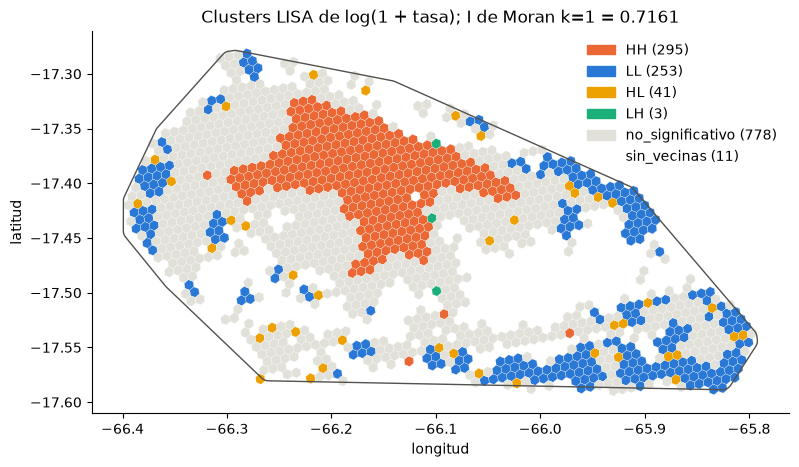

In [37]:
COLORES_LISA = {"HH": NARANJA, "LL": AZUL, "HL": AMARILLO, "LH": AQUA, "no_significativo": "#e1e0d9", "sin_vecinas": "#ffffff"}
g = gpd.GeoDataFrame(ctx.select("h3_cell", "lisa").to_pandas(), geometry=prep.cell_polygons(zonas), crs="EPSG:4326")
fig, ax = plt.subplots(figsize=(9, 8))
for tipo, color in COLORES_LISA.items():
    sub = g[g["lisa"] == tipo]
    if len(sub):
        sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.2)
gpd.GeoSeries([AREA], crs="EPSG:4326").boundary.plot(ax=ax, color=TINTA, lw=1)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORES_LISA.values()]
ax.legend(handles, [f"{k} ({(g['lisa'] == k).sum()})" for k in COLORES_LISA], frameon=False, loc="upper right")
ax.set(xlabel="longitud", ylabel="latitud", title=f"Clusters LISA de log(1 + tasa); I de Moran k=1 = {M['moran_I_k1']}")
tiempo("autocorrelacion")
guardar_figura(fig, "lisa", FASE)

## 12 · Cierre
**Tipo de datos:** documentación (diccionario de columnas) y de control (verificaciones y métricas).

Diccionario de las columnas crudas y verificaciones de coherencia. Los pasos que debe aplicar el
preprocesamiento, con su evidencia, están en `EXPLANATIONS.md` §5 (no se repiten aquí para no duplicar cifras).
**Salidas:** `diccionario_datos.csv`, `metricas.json`.

| Columna | Descripción |
|---|---|
| `date` | fecha y hora de la consulta (texto original) |
| `ts` | fecha y hora parseada |
| `userID` | instalación de la app |
| `lat_orig`, `lon_orig` | coordenadas de origen |
| `lat_dest`, `lon_dest` | coordenadas de destino |
| `distancia` | distancia origen–destino, en metros |
| `origin_municipio`, `dest_municipio` | municipio de origen/destino (geocodificación de Trufi) |
| `hour` | hora local |
| `day_of_week` | día de la semana (0 = lunes) |
| `day_of_month` | día del mes |
| `weekend` | 1 si es fin de semana |
| `year_week_number`, `time_of_day` | semana del año y franja horaria (solo lote 2024) |
| `year`, `week` | año y semana ISO, derivados de `ts` |
| `source_file`, `source_batch`, `source_encoding` | linaje: CSV de origen, lote de exportación y codificación |

In [38]:
# Tipo y % de nulos por columna (la descripción de cada una está en la tabla de arriba)
diccionario = pl.DataFrame([{"columna": c, "tipo": str(t), "pct_nulos": round(consultas[c].null_count() / N_CRUDAS * 100, 3)}
                            for c, t in consultas.schema.items()])
guardar_tabla(diccionario, "diccionario_datos", FASE)

columna,tipo,pct_nulos
str,str,f64
"""date""","""String""",0.0
"""lat_orig""","""Float64""",0.0
"""lon_orig""","""Float64""",0.0
"""lat_dest""","""Float64""",0.0
"""lon_dest""","""Float64""",0.0
…,…,…
"""year_week_number""","""String""",91.608
"""time_of_day""","""String""",91.608
"""ts""","""Datetime(time_unit='us', time_…",0.0


### Pasos para `02_preprocesamiento`

Evidencia de cada paso en la sección del EDA indicada; cifras exactas en `EXPLANATIONS.md` §4.

- Consolidar los CSV con un esquema y linaje (§3).
- Quitar orígenes en (0,0) y fuera de Bolivia, y las copias de duplicados exactos (§4).
- Delimitar la región con la componente H3 contigua (k=1) de orígenes válidos + 1 km (§6).
- Quitar consultas con distancia mayor al umbral configurado (§4).
- Excluir usuarios con señales de uso anómalo (§4).
- Contar consultas por zona H3 res 8 e incluir con 0 las zonas pobladas sin consultas (§8–9).
- No imputar el hueco; registrar semanas completas, parciales y faltantes (§5).
- Validar por bloques espaciales: la autocorrelación es alta y persiste a varios km (§11).

In [39]:
# Coherencia de lo explorado
assert flujo["filas_despues"][0] == N_CRUDAS and flujo["filas_despues"][-1] == limpias.height
assert flujo["filas_eliminadas"].sum() + limpias.height == N_CRUDAS
assert celdas["query_count"].sum() == limpias.height and (celdas["population"] >= 0).all()
assert celdas["h3_cell"].is_unique().all() and limpias.filter(pl.col("h3_origin").is_null()).height == 0
assert M["semanas_observadas"] + M["semanas_faltantes"] == M["semanas_calendario"]
assert M["semanas_completas"] + M["semanas_parciales"] == M["semanas_observadas"]
assert not limpias["userID"].is_in(anomalos["userID"].implode()).any(), "Quedan usuarios anómalos"
print("Verificaciones superadas")

Verificaciones superadas


In [40]:
# Tamaño medio de la unidad (tabla H3 v4) y parámetros usados
for r in (config.H3_RES, config.H3_RES_BLOQUE):
    M[f"h3_res{r}_area_km2"] = round(h3.average_hexagon_area(r, "km^2"), 3)
    M[f"h3_res{r}_arista_km"] = round(h3.average_hexagon_edge_length(r, "km"), 3)
M.update({"semilla": config.SEMILLA, "dist_max_m": config.DIST_MAX_M, "buffer_area_m": config.BUFFER_AREA_M,
          "pop_min": config.POP_MIN, "cobertura_m": config.COBERTURA_M, "permutaciones": config.PERMUTACIONES})
ruta = guardar_metricas(FASE, M)
tiempo("cierre")
print(f"{len(M)} métricas → {ruta.relative_to(config.PROJECT_ROOT)}")

⏱ cierre: 1.2 s (acumulado 126 s)
103 métricas → resultados/01_eda/metricas.json
